In [3]:
from google.colab import files
uploaded = files.upload()

Saving far_extrapolation_test.csv to far_extrapolation_test.csv
Saving training_set.csv to training_set.csv
Saving near_extrapolation_test.csv to near_extrapolation_test.csv
Saving interpolation_test.csv to interpolation_test.csv


In [4]:
far_expo_test,train,near_expo_test,inter_polation_test = uploaded

**Experiment 1 : - Goal**
To establish SEMF(Semi Empirical Mass Formula) and refit and test it


In [5]:
import numpy as np
import pandas as pd
far_test = pd.read_csv(far_expo_test)
train = pd.read_csv(train)
near_test = pd.read_csv(near_expo_test)
inter_test = pd.read_csv(inter_polation_test)
#We are using least squares to refit the coefficents of the prestigous SEMF.

In [6]:
def semf_matrix(train):
  Z = train['Z'].to_numpy(dtype=float)
  N = train['N'].to_numpy(dtype=float)
  A = Z+N

  pairing = np.where(
      (Z%2==0) & (N%2==0),1.0,
      np.where(
          (Z%2==1) & (N%2==1),-1.0,
          0.0
      )
  )
  X = np.column_stack([A,-A**(2/3),-Z*(Z-1)/A**(1/3),-(N-Z)**2/A,pairing/A**(1/2)])
  return X

In [7]:
train.columns

Index(['N', 'Z', 'binding', 'A', 'binding_MeV', 'binding_per_nucleon_MeV',
       'N_minus_Z', 'N_frontier', 'd'],
      dtype='object')

In [12]:
train.head()

,N,Z,binding,A,binding_MeV,binding_per_nucleon_MeV,N_minus_Z,N_frontier,d
0,82,56,8393.4222,138,1158.292264,8.393422,26,86.0,-4.0
1,28,26,8736.3846,54,471.764768,8.736385,2,40.7,-12.7
2,59,50,8470.5183,109,923.286495,8.470518,9,77.7,-18.7
3,118,86,7780.5743,204,1587.237157,7.780574,32,133.6,-15.6
4,26,18,8493.8411,44,373.729008,8.493841,8,28.1,-2.1


In [13]:
X = semf_matrix(train)
y = train['binding_MeV'].to_numpy()# Prepared train and test

In [19]:
coefficents,residuals,ranks,sing_val = np.linalg.lstsq(X,y,rcond=None)# I only need coefficents here
av,a_s,ac,aa,ap = coefficents

In [20]:
print('Volume :', av)
print('Surface :',a_s)
print('Coulomb :' ,ac)
print('Asymmetry:', aa)
print('Pairing :' , ap)

Volume : 15.473935312046446
Surface : 17.11126133334149
Coulomb : 0.6956988919834082
Asymmetry: 22.954078627804225
Pairing : 10.076187829059986


Volume : 15.473935312046446
Surface : 17.11126133334149
Coulomb : 0.6956988919834082
Asymmetry: 22.954078627804225
Pairing : 10.076187829059986


In [ ]:
# We refitted value for the SEMF .Now time to put these to work.
np.save('semf_cpff.npy',coefficents)


In [ ]:
files.download('semf_cpff.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# SEMF
def semf(test,av,aS,ac,aa,ap):
  Z = test['Z'].to_numpy(dtype=float)
  N = test['N'].to_numpy(dtype=float)
  A = Z+N

  pairing = np.where(
      (Z%2==0) & (N%2==0),1.0,
      np.where(
          (Z%2==1) & (N%2==1),-1.0,
          0.0)
      )
  return av*A - aS*A**(2/3) - ac*Z*(Z-1)/A**(1/3) - aa*(N-Z)**2/A + ap*pairing/A**(1/2)



In [ ]:
#Testing SEMF in INTERPOLATION
#Expectation: ABS ERROR VALUR WOULD BR LEAST HERE

In [28]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [25]:
Pred_inter = semf(inter_test,av,a_s,ac,aa,ap) #Predicted energies

In [26]:
Y_true = inter_test['binding_MeV'].to_numpy() #True energies

In [29]:
mse = mean_squared_error(Y_true,Pred_inter)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_true,Pred_inter)
print('MSE :',mse)
print('RMSE :',rmse)
print('MAE :',mae)

MSE : 11.517225485718948
RMSE : 3.3937038005281113
MAE : 2.1720369806804465


**Interpolation Test Results**

---



**MSE** : 11.517 **MeV**

**RMSE** : 3.3937038005281113 **MeV**

**MAE** : 2.1720369806804465 **MeV**

---




In [ ]:
#As we expected , error is around approximately arround 2 MeV

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

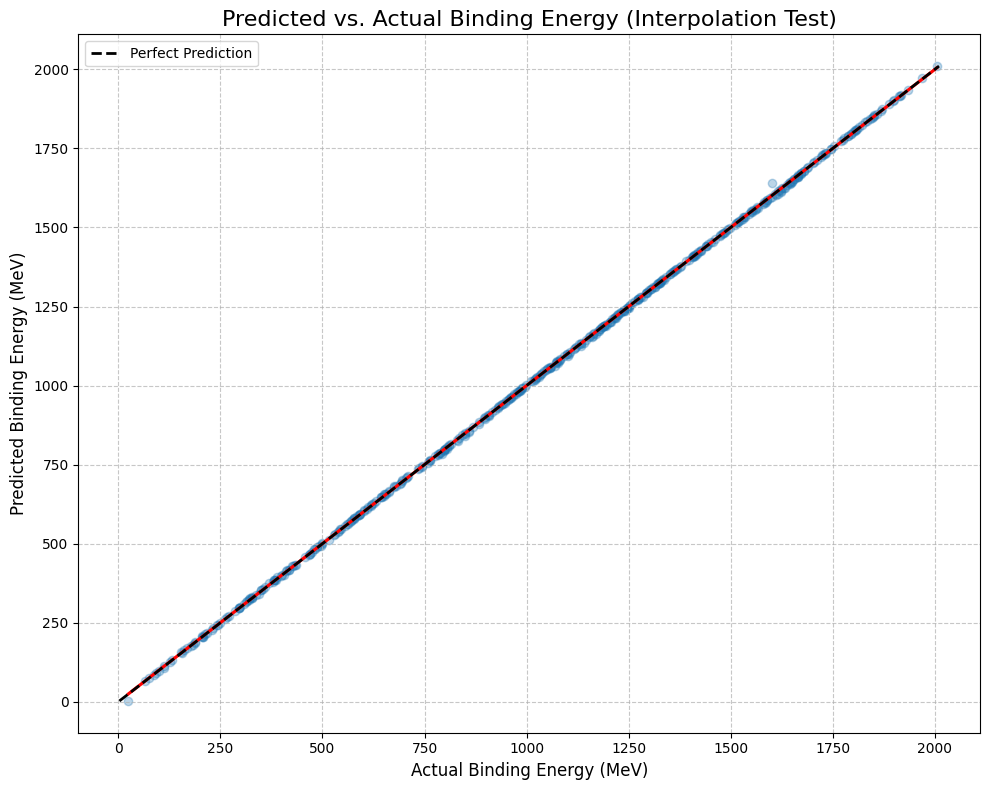

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

sns.regplot(x=Y_true, y=Pred_inter, ax=ax, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})


max_val = max(Y_true.max(), Pred_inter.max())
min_val = min(Y_true.min(), Pred_inter.min())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

ax.set_title('Predicted vs. Actual Binding Energy (Interpolation Test)', fontsize=16)
ax.set_xlabel('Actual Binding Energy (MeV)', fontsize=12)
ax.set_ylabel('Predicted Binding Energy (MeV)', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.savefig('predicted_vs_actual_binding_energy(Interpolation-SEMF).png')

from google.colab import files
files.download('predicted_vs_actual_binding_energy(Interpolation-SEMF).png')

plt.tight_layout()
plt.show()

In [33]:
#Near Extrapolation Test
Y_expo_pred = semf(near_test,av,a_s,ac,aa,ap)
Y_expo_true = near_test['binding_MeV'].to_numpy()

In [36]:
mae = mean_absolute_error(Y_expo_true,Y_expo_pred)
mse = mean_squared_error(Y_expo_true,Y_expo_pred)
rmse = np.sqrt(mse)
print('MSE :',mse)
print('RMSE :',rmse)
print('MAE :',mae)

MSE : 36.88444551543377
RMSE : 6.073256582380969
MAE : 4.371482250631066


**NEAR - EXTRApolation Test Results**

---



**MSE** : 36.88444551543377 **MeV**

**RMSE** : 6.073256582380969 **MeV**

**MAE** : 4.371482250631066 **MeV**

---

For near interpolation , we got MAE and RMSE almost got doubled ,partly becuase SEMF captures macroscopic effects but leave shell effects.

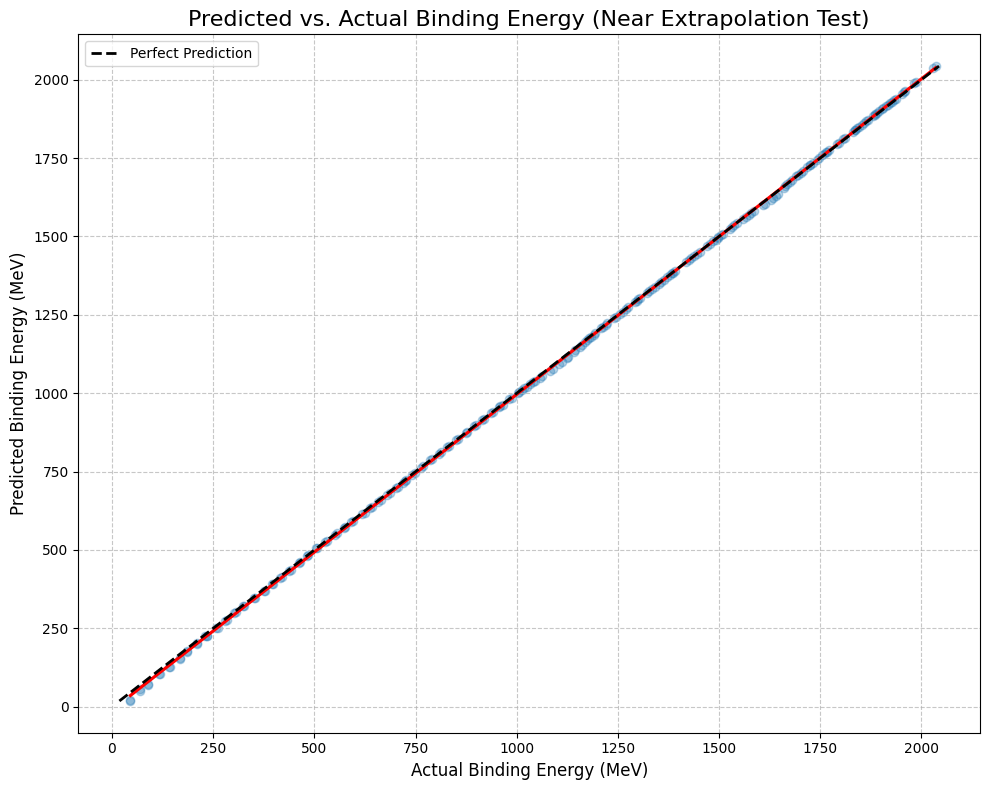

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.regplot(x=Y_expo_true, y=Y_expo_pred, ax=ax, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

max_val_expo = max(Y_expo_true.max(), Y_expo_pred.max())
min_val_expo = min(Y_expo_true.min(), Y_expo_pred.min())
ax.plot([min_val_expo, max_val_expo], [min_val_expo, max_val_expo], 'k--', lw=2, label='Perfect Prediction')

ax.set_title('Predicted vs. Actual Binding Energy (Near Extrapolation Test)', fontsize=16)
ax.set_xlabel('Actual Binding Energy (MeV)', fontsize=12)
ax.set_ylabel('Predicted Binding Energy (MeV)', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plot_filename = 'predicted_vs_actual_binding_energy(Near-Extrapolation-SEMF).png'
plt.savefig(plot_filename)
files.download(plot_filename)

In [38]:
# Conducing Far Extrapolation Test
Y_far_pred = semf(far_test,av,a_s,ac,aa,ap)
Y_far_true = far_test['binding_MeV'].to_numpy()
mae = mean_absolute_error(Y_far_true,Y_far_pred)
mse = mean_squared_error(Y_far_true,Y_far_pred)
rmse = np.sqrt(mse)
print('MSE :',mse)
print('RMSE :',rmse)
print('MAE :',mae)

MSE : 44.15858245083771
RMSE : 6.645192431437762
MAE : 5.194496688161672


**FAR - EXTRAPOLATION - TEST RESULTS**



---
MSE : 44.15858245083771

RMSE : 6.645192431437762

MAE : 5.194496688161672


---





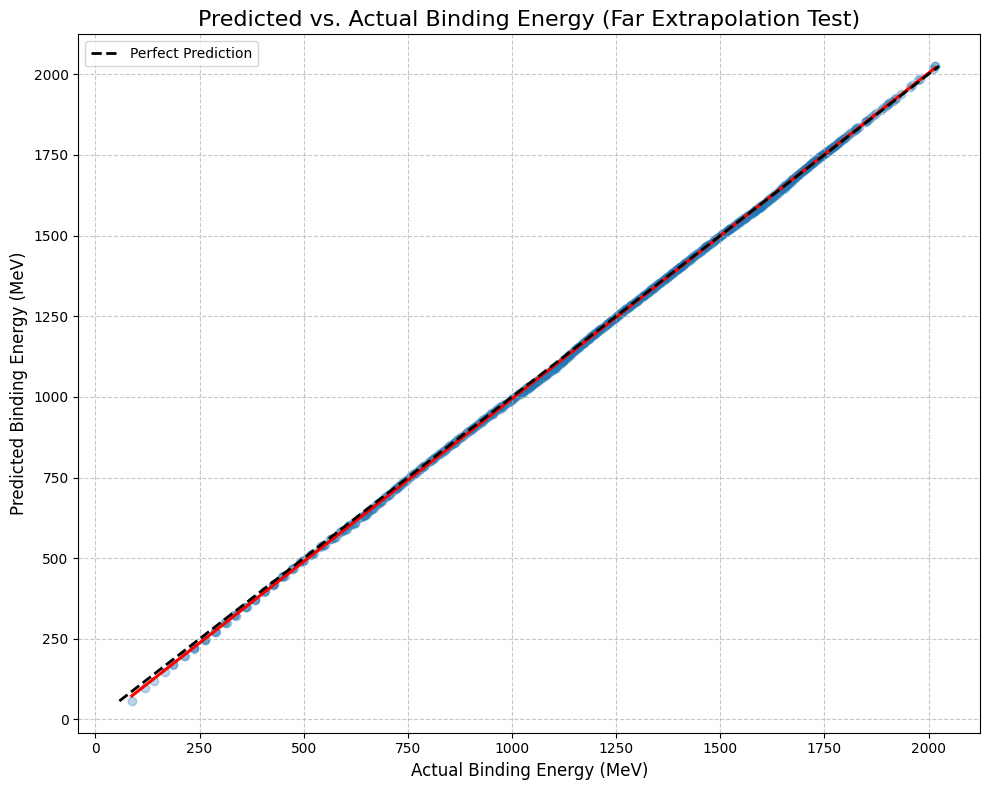

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.regplot(x=Y_far_true, y=Y_far_pred, ax=ax, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

max_val_far = max(Y_far_true.max(), Y_far_pred.max())
min_val_far = min(Y_far_true.min(), Y_far_pred.min())
ax.plot([min_val_far, max_val_far], [min_val_far, max_val_far], 'k--', lw=2, label='Perfect Prediction')

ax.set_title('Predicted vs. Actual Binding Energy (Far Extrapolation Test)', fontsize=16)
ax.set_xlabel('Actual Binding Energy (MeV)', fontsize=12)
ax.set_ylabel('Predicted Binding Energy (MeV)', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plot_filename_far = 'predicted_vs_actual_binding_energy(Far-Extrapolation-SEMF).png'
plt.savefig(plot_filename_far)
files.download(plot_filename_far)

## Error Metric Comparison

| Test Set             | MSE (MeV)        | RMSE (MeV)       |
| :------------------- | :--------------- | :--------------- |
| Interpolation Test   | 11.517           | 3.394            |
| Near Extrapolation   | 36.884           | 6.073            |
| Far Extrapolation    | 44.159           | 6.645            |

**Observations:**

As expected, the errors generally increase as we move from interpolation to near extrapolation, and then to far extrapolation. This indicates that the SEMF model performs best on data similar to its training set and its performance degrades when applied to data further away from its training distribution. The RMSE values consistently reflect this trend, providing a measure of the average magnitude of the errors in the same units as the binding energy (MeV).

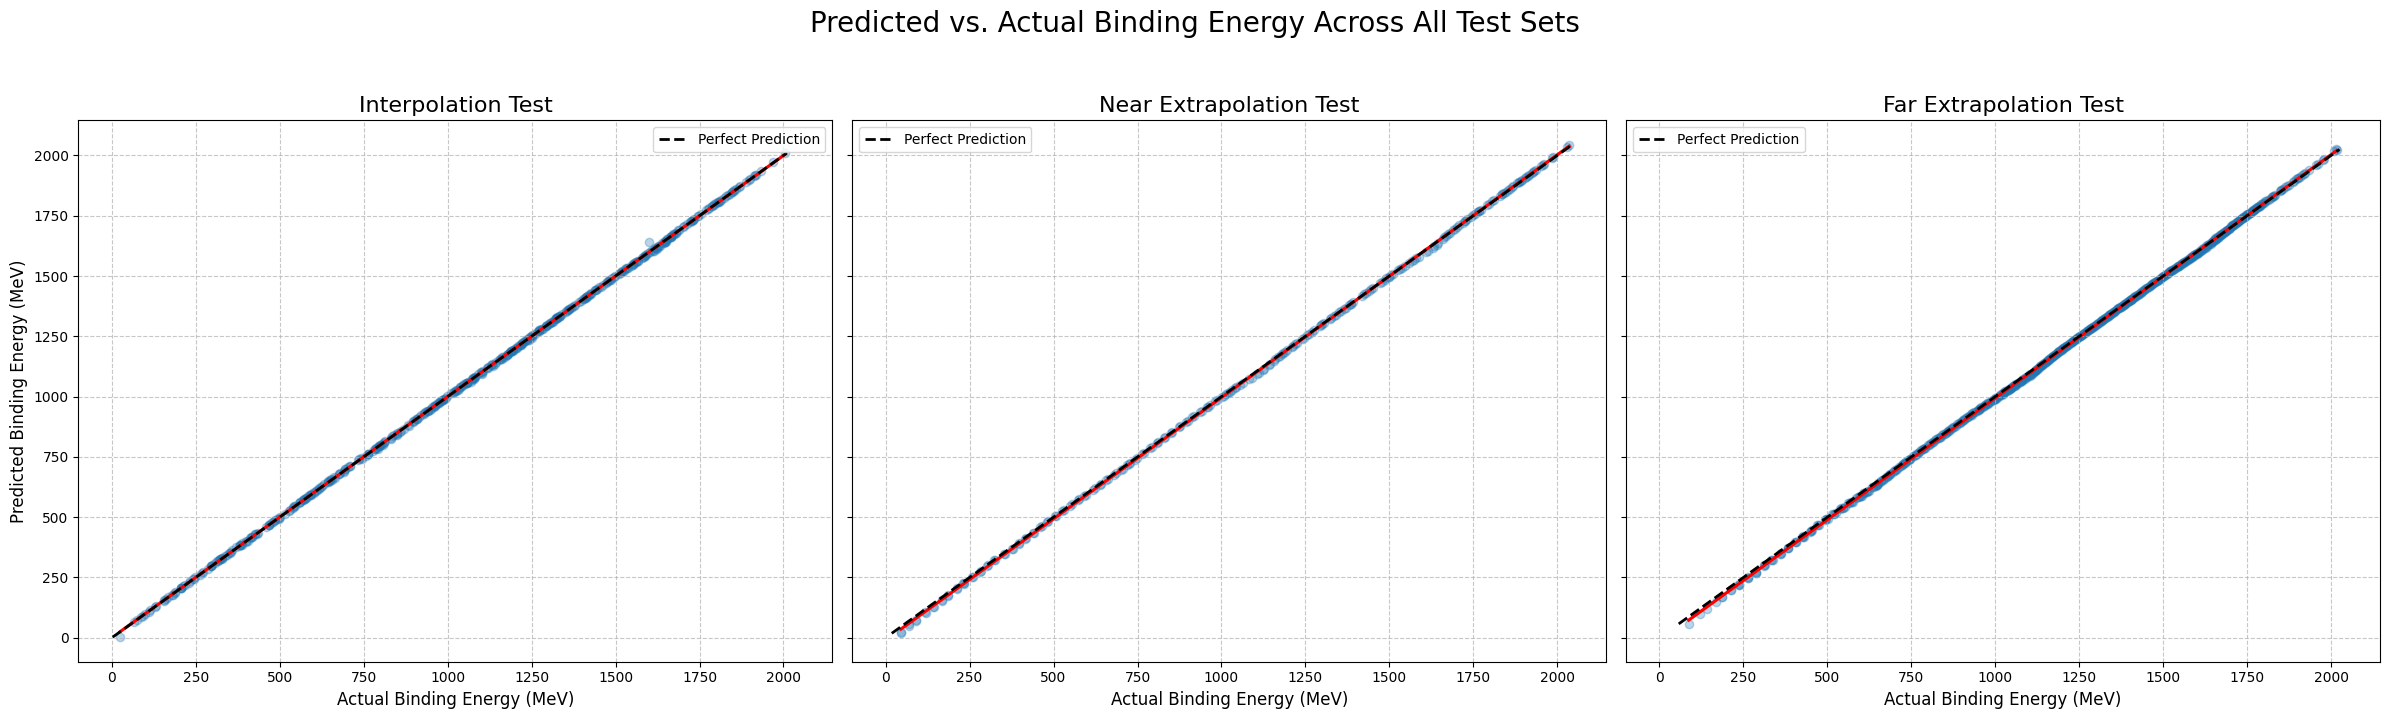

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharex=True, sharey=True)

sns.regplot(x=Y_true, y=Pred_inter, ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
max_val_inter = max(Y_true.max(), Pred_inter.max())
min_val_inter = min(Y_true.min(), Pred_inter.min())
axes[0].plot([min_val_inter, max_val_inter], [min_val_inter, max_val_inter], 'k--', lw=2, label='Perfect Prediction')
axes[0].set_title('Interpolation Test', fontsize=16)
axes[0].set_xlabel('Actual Binding Energy (MeV)', fontsize=12)
axes[0].set_ylabel('Predicted Binding Energy (MeV)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.regplot(x=Y_expo_true, y=Y_expo_pred, ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
max_val_near = max(Y_expo_true.max(), Y_expo_pred.max())
min_val_near = min(Y_expo_true.min(), Y_expo_pred.min())
axes[1].plot([min_val_near, max_val_near], [min_val_near, max_val_near], 'k--', lw=2, label='Perfect Prediction')
axes[1].set_title('Near Extrapolation Test', fontsize=16)
axes[1].set_xlabel('Actual Binding Energy (MeV)', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

sns.regplot(x=Y_far_true, y=Y_far_pred, ax=axes[2], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
max_val_far = max(Y_far_true.max(), Y_far_pred.max())
min_val_far = min(Y_far_true.min(), Y_far_pred.min())
axes[2].plot([min_val_far, max_val_far], [min_val_far, max_val_far], 'k--', lw=2, label='Perfect Prediction')
axes[2].set_title('Far Extrapolation Test', fontsize=16)
axes[2].set_xlabel('Actual Binding Energy (MeV)', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Predicted vs. Actual Binding Energy Across All Test Sets', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

combined_plot_filename = 'predicted_vs_actual_binding_energy_all_tests.png'
plt.savefig(combined_plot_filename)
files.download(combined_plot_filename)